# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [2]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [3]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 32.8 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


### Import Statements

In [4]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [5]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [6]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [7]:
df_data.shape

(4324, 9)

In [8]:
df_data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [9]:
df_data.isna().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
Organisation,0
Location,0
Date,0
Detail,0
Rocket_Status,0
Price,3360
Mission_Status,0


In [10]:
df_data.duplicated().sum()

np.int64(0)

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [11]:
df_data['Price'] = df_data['Price'].astype(str).str.replace(',', '', regex=False)
df_data['Price'] = pd.to_numeric(df_data['Price'], errors='coerce')

## Descriptive Statistics

In [12]:
df_data.describe()

,Unnamed: 0.1,Unnamed: 0,Price
count,"4,324.00","4,324.00",964.00
mean,"2,161.50","2,161.50",153.79
std,"1,248.38","1,248.38",288.45
min,0.00,0.00,5.30
25%,"1,080.75","1,080.75",40.00
50%,"2,161.50","2,161.50",62.00
75%,"3,242.25","3,242.25",164.00
max,"4,323.00","4,323.00","5,000.00"


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [13]:
df_data.groupby('Organisation')['Organisation'].count().sort_values(ascending=False)

,Organisation
Organisation,
RVSN USSR,1777
Arianespace,279
General Dynamics,251
CASC,251
NASA,203
VKS RF,201
US Air Force,161
ULA,140
Boeing,136


<Axes: ylabel='Organisation'>

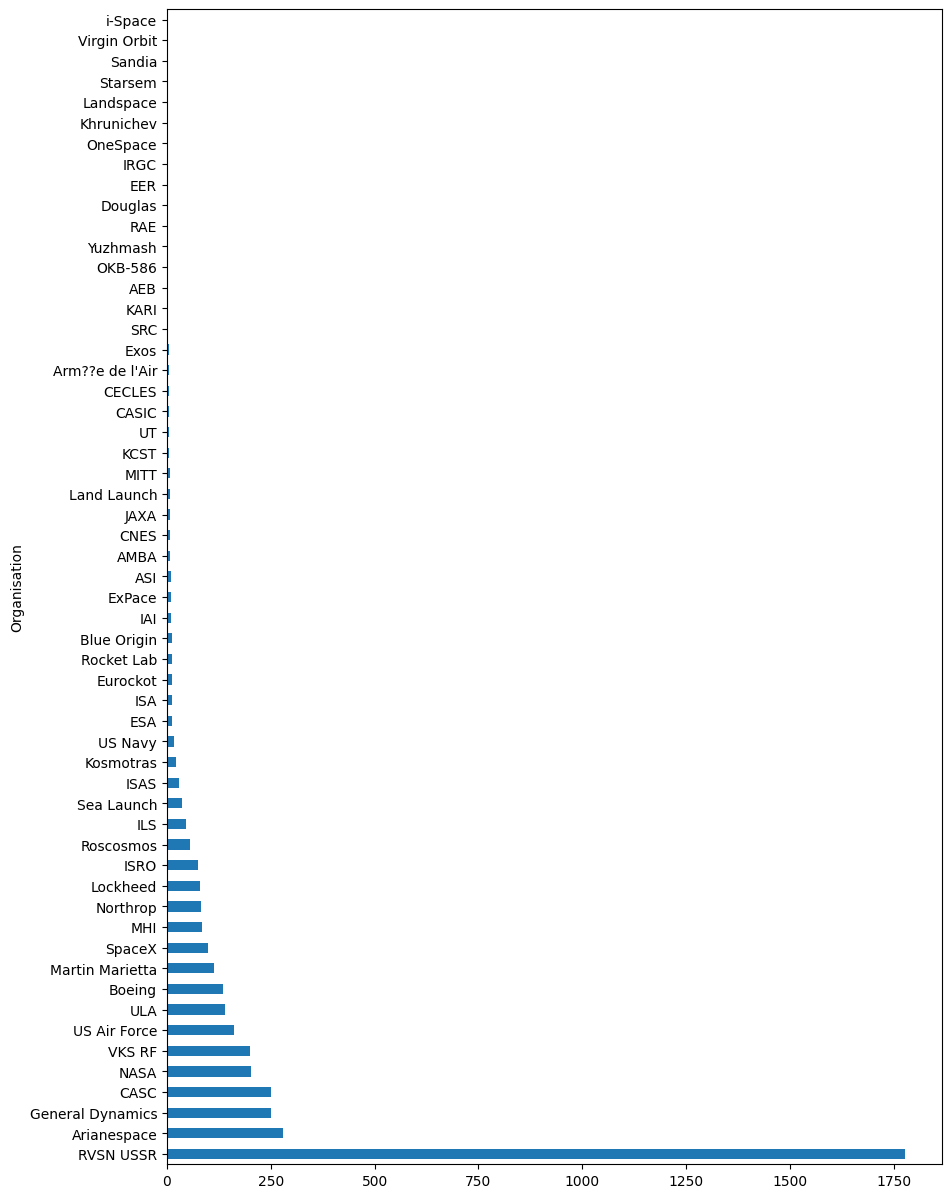

In [14]:
df_data.groupby('Organisation')['Organisation'].count().sort_values(ascending=False).plot(kind='barh', figsize=(10, 15))

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [15]:
count = df_data.groupby('Rocket_Status')['Rocket_Status'].count()
active_rockets = count['StatusActive']
retired_rockets = count['StatusRetired']
print(f"{active_rockets} artive and {retired_rockets} retireted rockets")

790 artive and 3534 retireted rockets


# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [16]:
mission_status_count = df_data.groupby('Mission_Status')['Mission_Status'].count()
success = mission_status_count['Success']
failure = mission_status_count['Failure']
print(f"{success} missions were successful and {failure} missions failed")

3879 missions were successful and 339 missions failed


# How Expensive are the Launches?

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values).

<Axes: title={'center': 'How Expensive are the Launches?'}, ylabel='Frequency'>

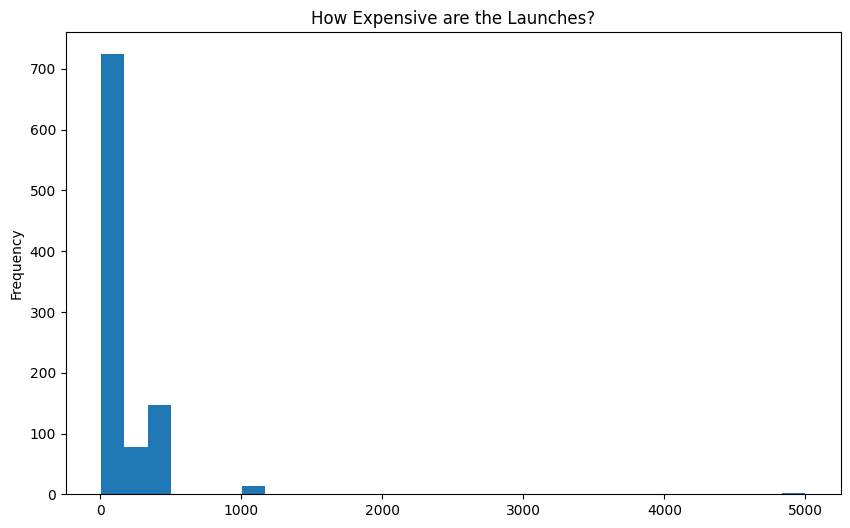

In [17]:
df_data_clear = df_data.dropna(subset=['Price']).copy()
df_data_clear['Price'] = pd.to_numeric(df_data_clear['Price'], errors='coerce')
df_data_clear['Price'].plot(kind='hist', bins=30, figsize=(10, 6), title='How Expensive are the Launches?' )

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [18]:
df_data_new = df_data.copy()
df_data_new['Country'] = df_data_new['Location'].str.split(',').str[-1].str.strip()

country_replacements = {
    'Russia': 'Russian Federation',
    'New Mexico': 'USA',
    'Yellow Sea': 'China',
    'Shahrud Missile Test Site': 'Iran, Islamic Republic of',
    'Pacific Missile Range Facility': 'USA',
    'Barents Sea': 'Russian Federation',
    'Gran Canaria': 'USA',
    'Iran': 'Iran, Islamic Republic of',
    'South Korea': 'Korea, Republic of',
    'North Korea': "Korea, Democratic People's Republic of"
}

df_data_new['Country'] = df_data_new['Country'].replace(country_replacements)

def get_iso3(country_name):
    try:
        return countries.get(country_name).alpha3
    except KeyError:
        return None

df_data_new['ISO'] = df_data_new['Country'].apply(get_iso3)

launches_per_country = df_data_new.groupby(['ISO', 'Country']).size().reset_index(name='Launches')

choropleth_map = px.choropleth(launches_per_country, locations="ISO", color="Launches", hover_name="Country", color_continuous_scale="matter", title="Number of Launches by Country")

choropleth_map.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [19]:
df_failures = df_data_new[df_data_new['Mission_Status'].str.contains('Failure', na=False)]

failures_per_country = df_failures.groupby(['ISO', 'Country']).size().reset_index(name='Failures')

fig_failures = px.choropleth(failures_per_country, locations="ISO", color="Failures", hover_name="Country", color_continuous_scale="matter", title="Number of Mission Failures by Country")

fig_failures.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status.

In [20]:
sunburst_data = df_data_new.groupby(['Country', 'Organisation', 'Mission_Status']).size().reset_index(name='Launches')

fig_sunburst = px.sunburst(sunburst_data, path=['Country', 'Organisation', 'Mission_Status'], values='Launches', title='Space Missions by Country, Organisation, and Status', color='Mission_Status')

fig_sunburst.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions


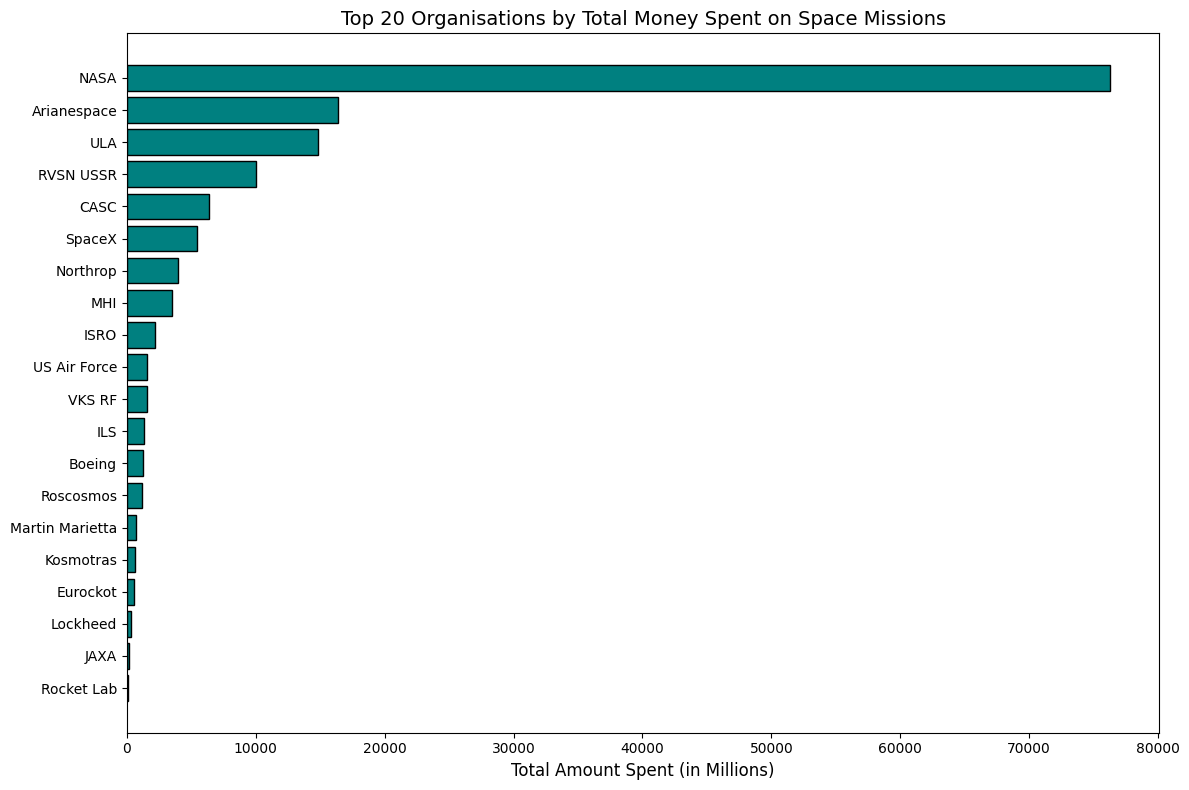

In [21]:
df_data_clear_price = df_data_clear.copy()

df_data_clear_price['Price'] = df_data_clear_price['Price'].astype(str).str.replace(',', '')
df_data_clear_price['Price'] = pd.to_numeric(df_data_clear_price['Price'], errors='coerce')

df_data_clear_price = df_data_clear_price.dropna(subset=['Price']).copy()

total_spent = df_data_clear_price.groupby('Organisation')['Price'].sum().sort_values(ascending=False).reset_index()

top_20 = total_spent.head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_20['Organisation'][::-1], top_20['Price'][::-1], color='teal', edgecolor='black')

plt.xlabel('Total Amount Spent (in Millions)', fontsize=12)
plt.title('Top 20 Organisations by Total Money Spent on Space Missions', fontsize=14)
plt.tight_layout()

plt.show()

# Analyse the Amount of Money Spent by Organisation per Launch

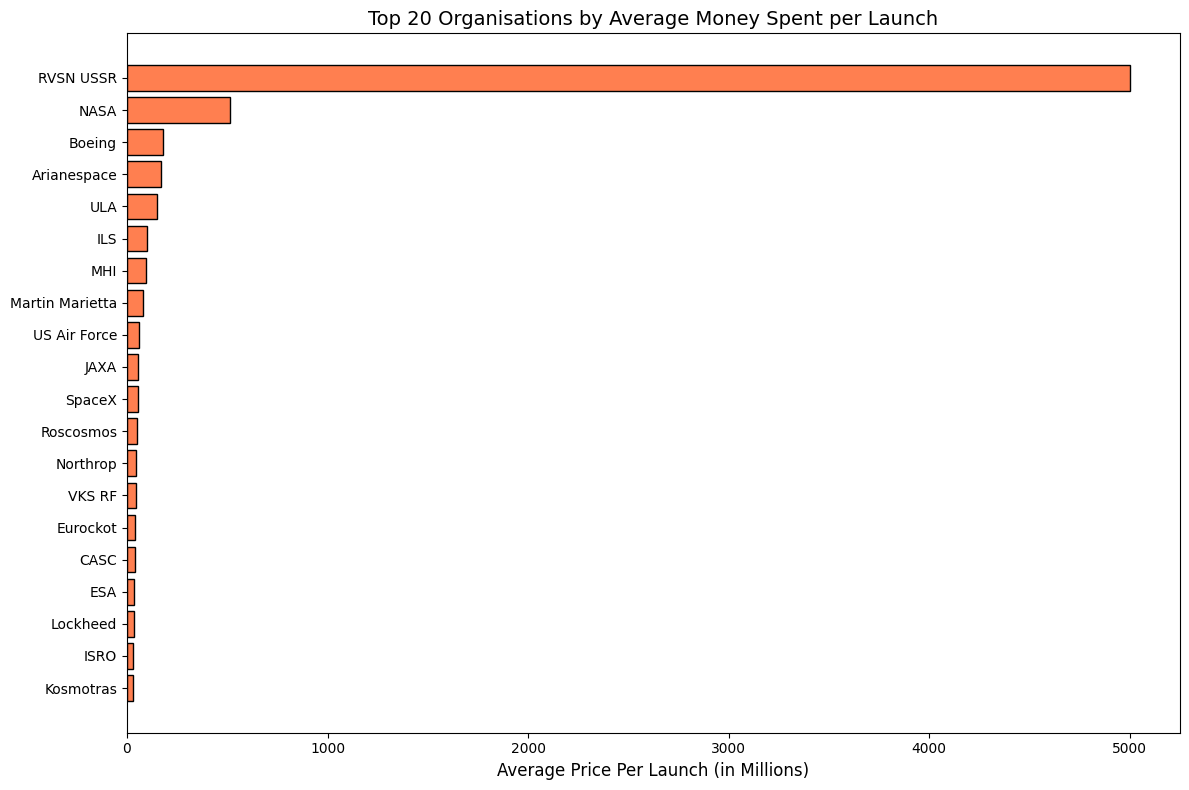

In [22]:
cost_per_launch = df_data_clear_price.groupby('Organisation')['Price'].agg(['mean', 'count']).sort_values(by='mean', ascending=False).reset_index()

cost_per_launch.columns = ['Organisation', 'Average_Price_Per_Launch', 'Number_of_Launches']

plt.figure(figsize=(12, 8))
top_20 = cost_per_launch.head(20)

plt.barh(top_20['Organisation'][::-1], top_20['Average_Price_Per_Launch'][::-1], color='coral', edgecolor='black')

plt.xlabel('Average Price Per Launch (in Millions)', fontsize=12)
plt.title('Top 20 Organisations by Average Money Spent per Launch', fontsize=14)
plt.tight_layout()

plt.show()

# Chart the Number of Launches per Year

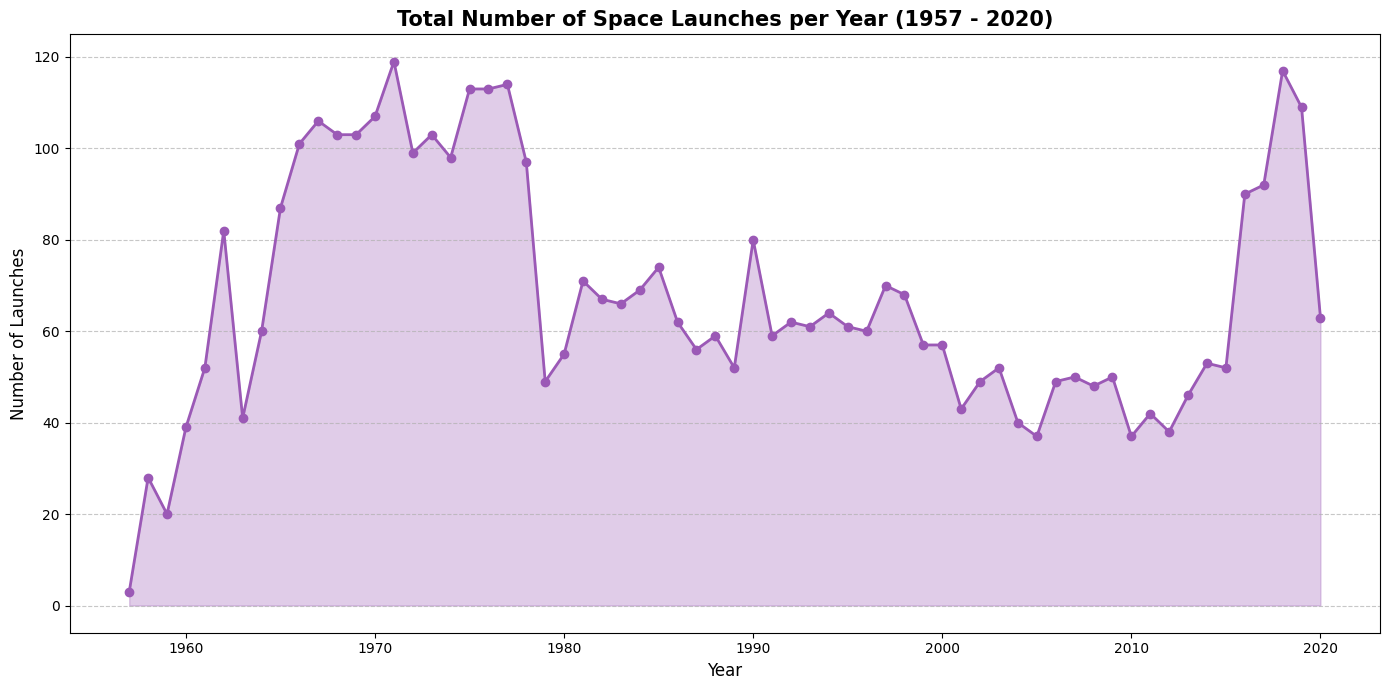

In [25]:
yearly_launches = df_data.copy()

yearly_launches['Year'] = yearly_launches['Date'].str.extract(r'([1-2][0-9]{3})').astype(float)

yearly_launches = yearly_launches['Year'].value_counts().sort_index().reset_index()
yearly_launches.columns = ['Year', 'Launches']

plt.figure(figsize=(14, 7))

plt.plot(yearly_launches['Year'], yearly_launches['Launches'], marker='o', linestyle='-', color='#9b59b6', linewidth=2)
plt.fill_between(yearly_launches['Year'], yearly_launches['Launches'], color='#9b59b6', alpha=0.3)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.title('Total Number of Space Launches per Year (1957 - 2020)', fontsize=15, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

/tmp/ipykernel_514/1204890774.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_launches = monthly_launches.groupby(monthly_launches['Date'].dt.to_period('M')).size().reset_index(name='Launches')


The most active month in space history was 1968-04-01 00:00:00 with 16 missions.


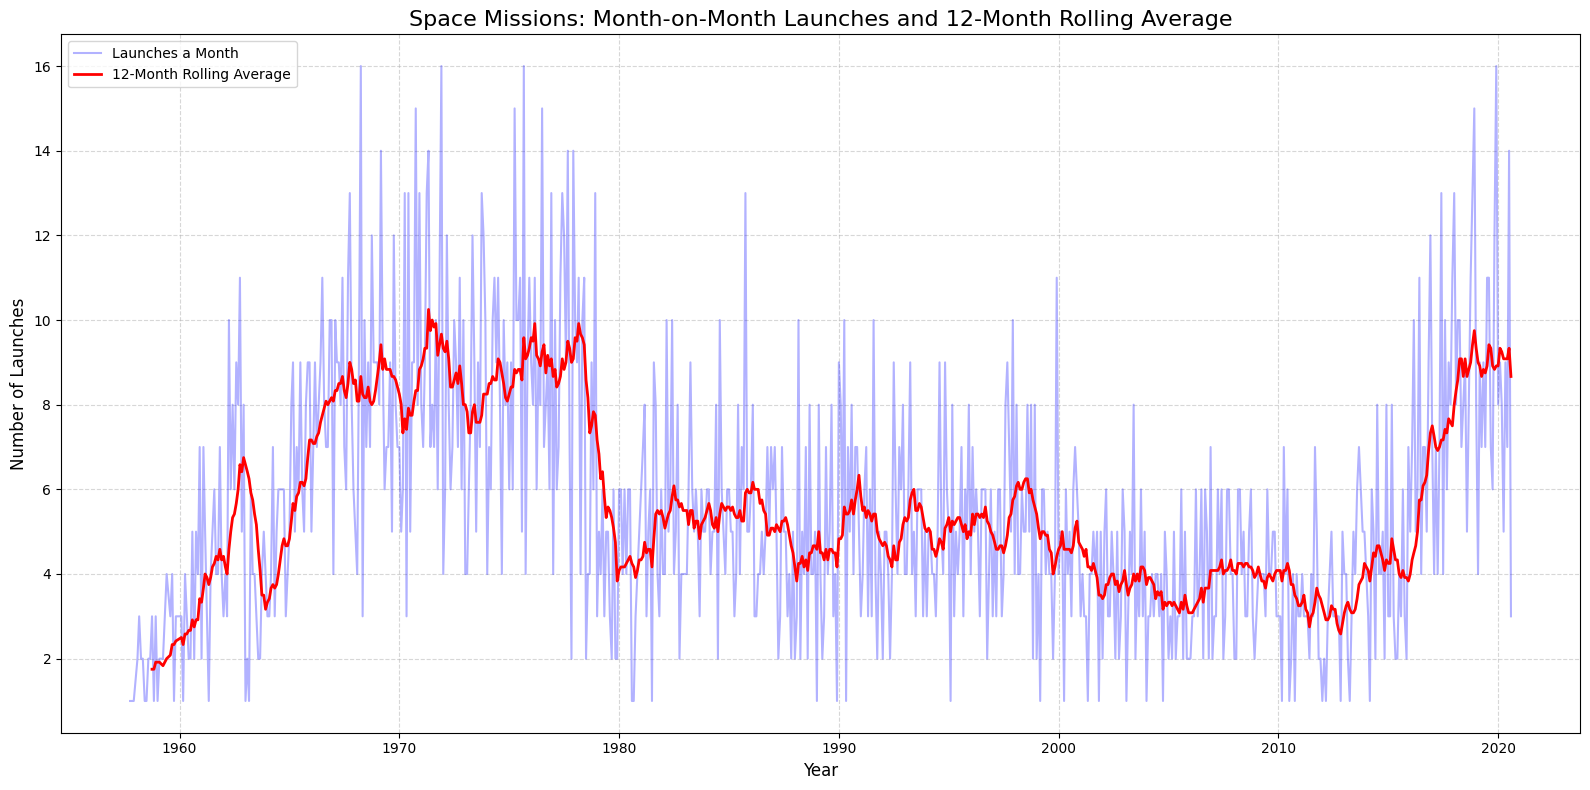

In [26]:
monthly_launches = df_data.copy()

monthly_launches['Date'] = pd.to_datetime(monthly_launches['Date'], utc=True, errors='coerce')
monthly_launches = monthly_launches.dropna(subset=['Date'])

monthly_launches = monthly_launches.groupby(monthly_launches['Date'].dt.to_period('M')).size().reset_index(name='Launches')
monthly_launches['Date'] = monthly_launches['Date'].dt.to_timestamp()

monthly_launches['Rolling_Avg'] = monthly_launches['Launches'].rolling(window=12).mean()

plt.figure(figsize=(16, 8))

plt.plot(monthly_launches['Date'], monthly_launches['Launches'],
         label='Launches a Month', color='blue', alpha=0.3)

plt.plot(monthly_launches['Date'], monthly_launches['Rolling_Avg'],
         label='12-Month Rolling Average', color='red', linewidth=2)

plt.title('Space Missions: Month-on-Month Launches and 12-Month Rolling Average', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

peak_val = monthly_launches['Launches'].max()
peak_date = monthly_launches.loc[monthly_launches['Launches'].idxmax(), 'Date']
print(f"The most active month in space history was {peak_date} with {peak_val} missions.")

plt.tight_layout()
plt.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

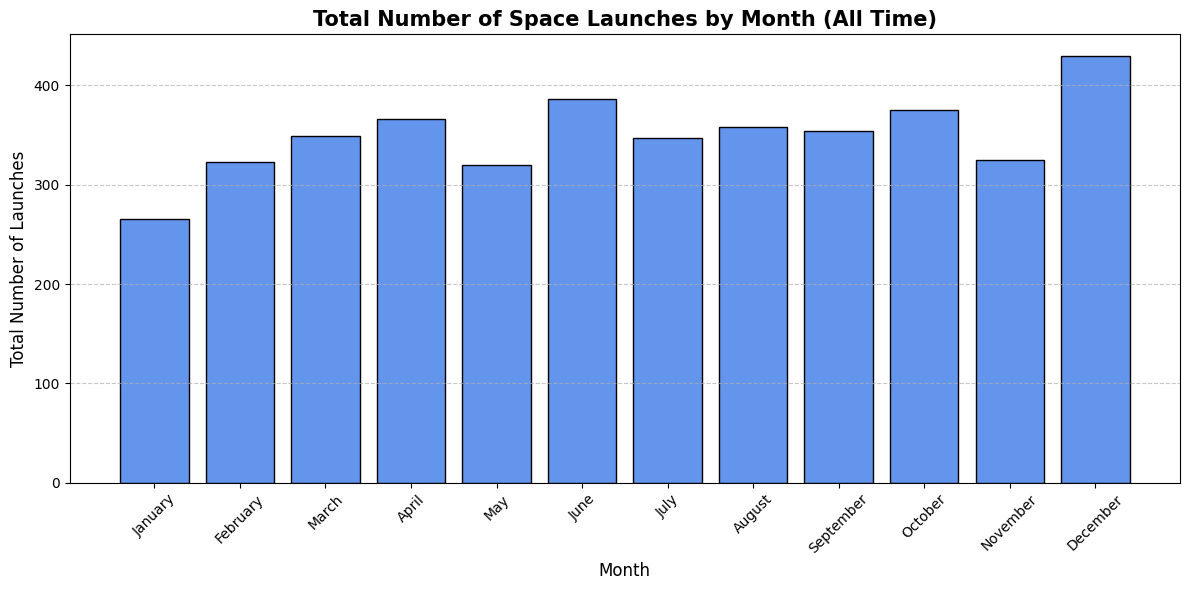

Launches per Month:
Month_Name  Launches
   January       265
  February       323
     March       349
     April       366
       May       320
      June       386
      July       347
    August       358
 September       354
   October       375
  November       325
  December       430


In [29]:
launches_per_month = df_data.copy()

launches_per_month['Date'] = pd.to_datetime(launches_per_month['Date'], utc=True, errors='coerce')

launches_per_month['Month_Num'] = launches_per_month['Date'].dt.month
launches_per_month['Month_Name'] = launches_per_month['Date'].dt.month_name()

monthly_counts = launches_per_month.groupby(['Month_Num', 'Month_Name']).size().reset_index(name='Launches')
monthly_counts = monthly_counts.sort_values('Month_Num')

plt.figure(figsize=(12, 6))
plt.bar(monthly_counts['Month_Name'], monthly_counts['Launches'], color='cornflowerblue', edgecolor='black')

plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Number of Launches', fontsize=12)
plt.title('Total Number of Space Launches by Month (All Time)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

print("Launches per Month:")
print(monthly_counts[['Month_Name', 'Launches']].to_string(index=False))

# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

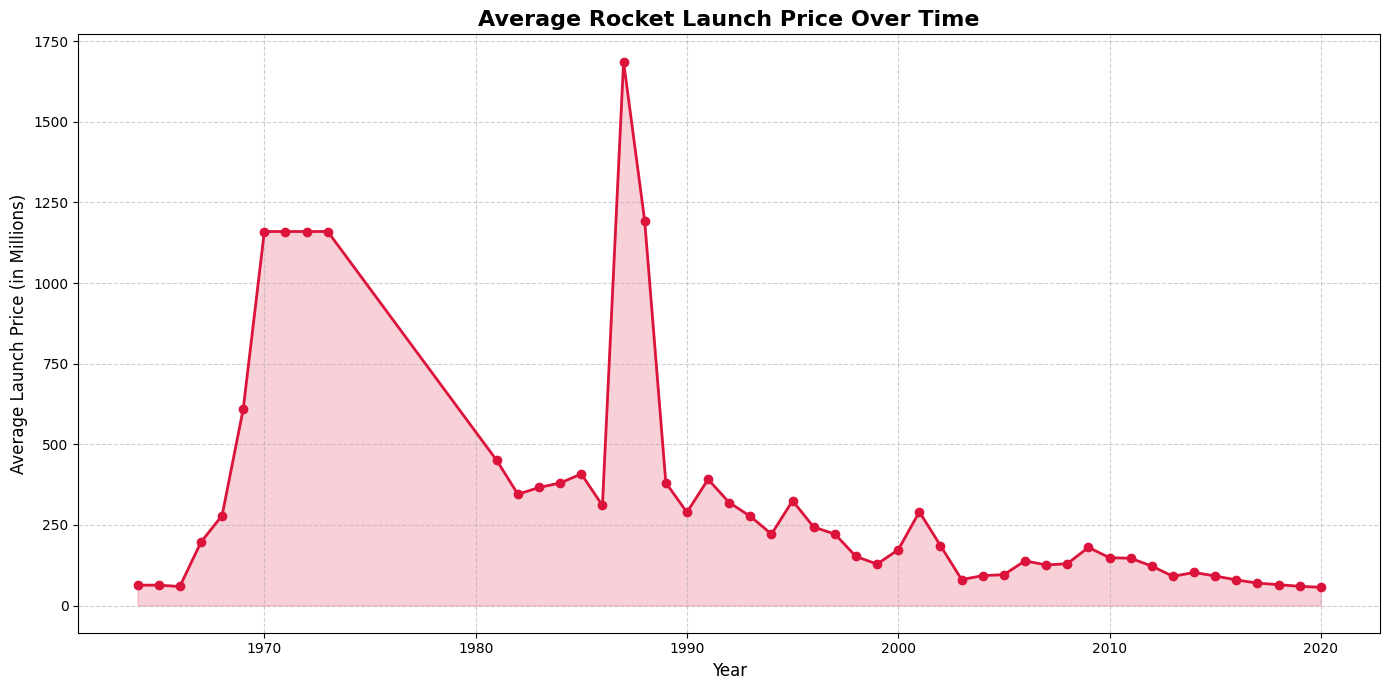

In [31]:
avg_price_per_year = df_data.copy()

avg_price_per_year['Year'] = avg_price_per_year['Date'].str.extract(r'([1-2][0-9]{3})').astype(float)

avg_price_per_year['Price'] = avg_price_per_year['Price'].astype(str).str.replace(',', '')
avg_price_per_year['Price'] = pd.to_numeric(avg_price_per_year['Price'], errors='coerce')

avg_price_per_year = avg_price_per_year.dropna(subset=['Price', 'Year'])

avg_price_per_year = avg_price_per_year.groupby('Year')['Price'].mean().reset_index()

plt.figure(figsize=(14, 7))

plt.plot(avg_price_per_year['Year'], avg_price_per_year['Price'], marker='o', linestyle='-', color='crimson', linewidth=2)
plt.fill_between(avg_price_per_year['Year'], avg_price_per_year['Price'], color='crimson', alpha=0.2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Launch Price (in Millions)', fontsize=12)
plt.title('Average Rocket Launch Price Over Time', fontsize=16, fontweight='bold')
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# Chart the Number of Launches over Time by the Top 10 Organisations.

How has the dominance of launches changed over time between the different players?

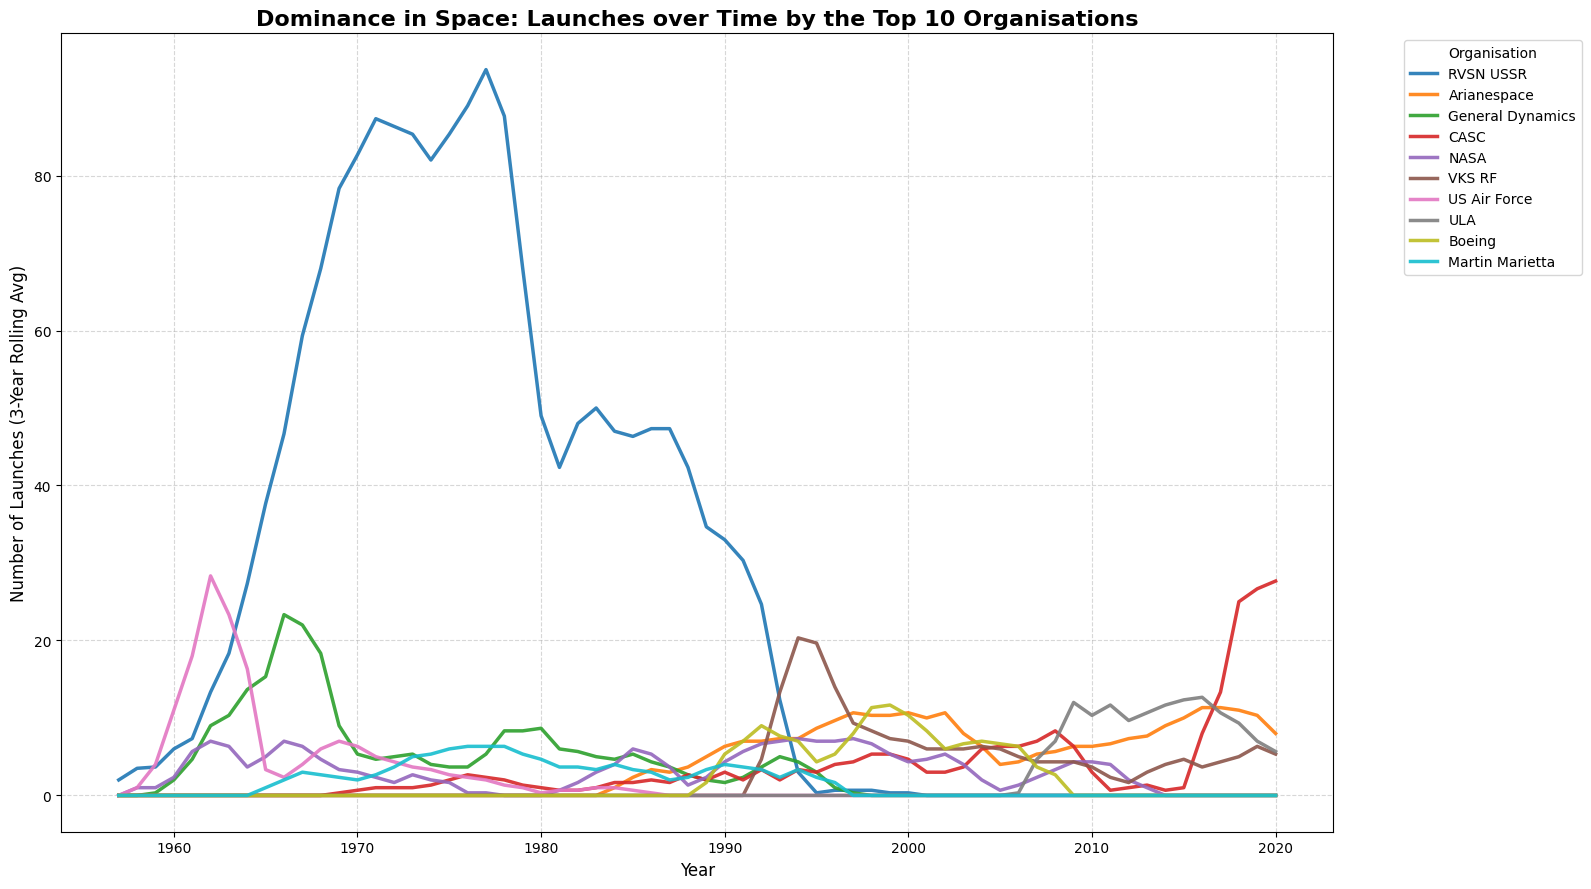

In [32]:
df_top10 = df_data.copy()

df_top10['Year'] = df_top10['Date'].str.extract(r'([1-2][0-9]{3})').astype(float)
top_10_orgs = df_top10['Organisation'].value_counts().nlargest(10).index.tolist()
df_top10 = df_top10[df_top10['Organisation'].isin(top_10_orgs)]

yearly_org_launches = df_top10.groupby(['Year', 'Organisation']).size().unstack(fill_value=0)

rolling_org_launches = yearly_org_launches.rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(16, 9))

colors = plt.cm.tab10.colors

for i, org in enumerate(top_10_orgs):
    plt.plot(rolling_org_launches.index, rolling_org_launches[org],
             label=org, color=colors[i], linewidth=2.5, alpha=0.9)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches (3-Year Rolling Avg)', fontsize=12)
plt.title('Dominance in Space: Launches over Time by the Top 10 Organisations', fontsize=16, fontweight='bold')

plt.legend(title='Organisation', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991.

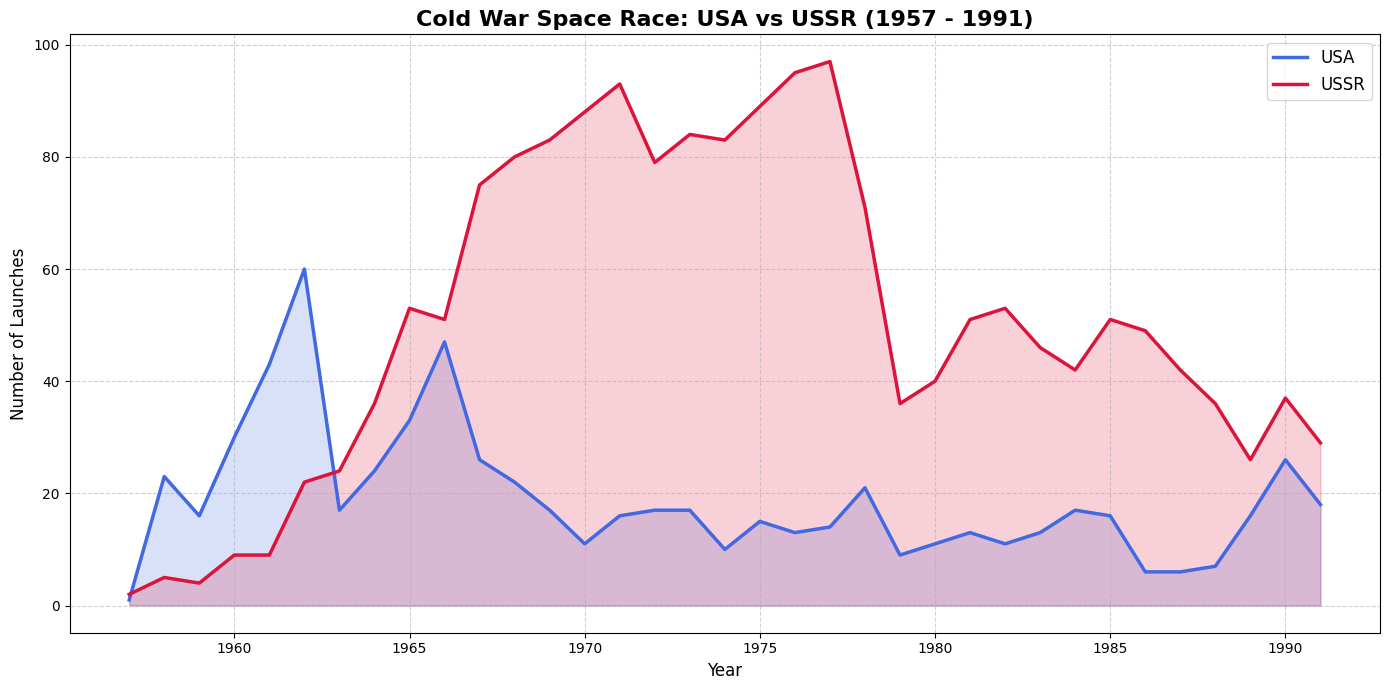

Superpower
USA      662
USSR    1770
dtype: int64


In [35]:
cold_war_df = df_data_new.copy()


cold_war_df['Year'] = cold_war_df['Date'].str.extract(r'([1-2][0-9]{3})').astype(float)

cold_war_df = cold_war_df[cold_war_df['Year'] <= 1991].copy()

def get_superpower(country):
    if country in ['Russian Federation', 'Kazakhstan']:
        return 'USSR'
    elif country == 'USA':
        return 'USA'
    else:
        return 'Other'

cold_war_df['Superpower'] = cold_war_df['Country'].apply(get_superpower)

superpower_df = cold_war_df[cold_war_df['Superpower'] != 'Other']
yearly_launches = superpower_df.groupby(['Year', 'Superpower']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))

plt.plot(yearly_launches.index, yearly_launches['USA'], label='USA', color='royalblue', linewidth=2.5)
plt.plot(yearly_launches.index, yearly_launches['USSR'], label='USSR', color='crimson', linewidth=2.5)

plt.fill_between(yearly_launches.index, yearly_launches['USA'], color='royalblue', alpha=0.2)
plt.fill_between(yearly_launches.index, yearly_launches['USSR'], color='crimson', alpha=0.2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.title('Cold War Space Race: USA vs USSR (1957 - 1991)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

print(yearly_launches.sum())

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches.

In [36]:
superpower_df = df_data_new.copy()

def get_superpower(country):
    if country in ['Russian Federation', 'Kazakhstan']:
        return 'USSR'
    elif country == 'USA':
        return 'USA'
    else:
        return 'Other'

superpower_df['Superpower'] = superpower_df['Country'].apply(get_superpower)

superpower_df = superpower_df[superpower_df['Superpower'] != 'Other']

total_launches = superpower_df['Superpower'].value_counts().reset_index()
total_launches.columns = ['Superpower', 'Total_Launches']

fig_pie = px.pie(
    total_launches,
    names='Superpower',
    values='Total_Launches',
    title='Total Space Launches: USA vs USSR (Including Kazakhstan)',
    color='Superpower',
    color_discrete_map={
        'USSR': '#d62728',
        'USA': '#1f77b4'
    },
    hole=0.4
)

fig_pie.update_traces(textposition='inside', textinfo='percent+label')

fig_pie.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

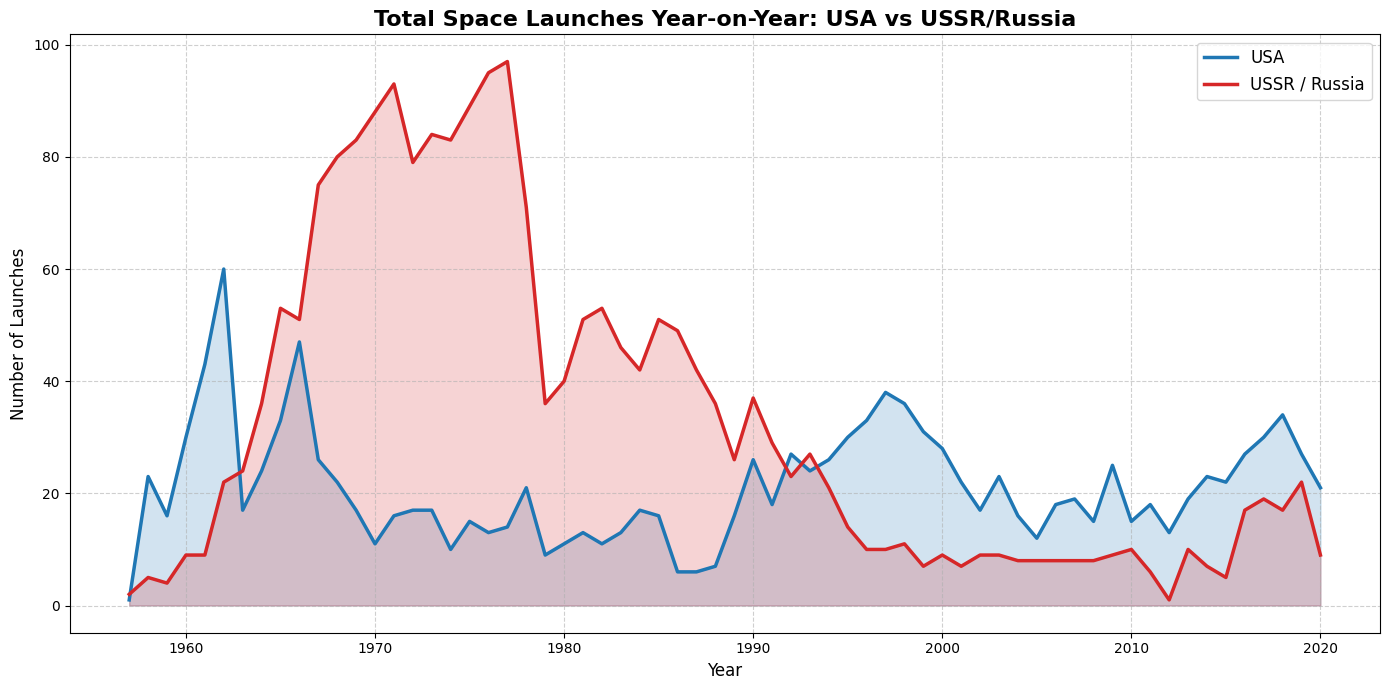

In [38]:
superpower_df = df_data_new.copy()

def get_superpower(country):
    if country in ['Russian Federation', 'Kazakhstan']:
        return 'USSR / Russia'
    elif country == 'USA':
        return 'USA'
    else:
        return 'Other'

superpower_df['Superpower'] = superpower_df['Country'].apply(get_superpower)

superpower_df['Year'] = superpower_df['Date'].str.extract(r'([1-2][0-9]{3})').astype(float)

superpower_df = superpower_df[superpower_df['Superpower'] != 'Other']
yearly_launches = superpower_df.groupby(['Year', 'Superpower']).size().unstack(fill_value=0)

# 6. Plot the data
plt.figure(figsize=(14, 7))

# Draw the lines
plt.plot(yearly_launches.index, yearly_launches['USA'], label='USA', color='#1f77b4', linewidth=2.5)
plt.plot(yearly_launches.index, yearly_launches['USSR / Russia'], label='USSR / Russia', color='#d62728', linewidth=2.5)

# Fill under the lines to make them pop
plt.fill_between(yearly_launches.index, yearly_launches['USA'], color='#1f77b4', alpha=0.2)
plt.fill_between(yearly_launches.index, yearly_launches['USSR / Russia'], color='#d62728', alpha=0.2)

# Format the chart to look professional
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.title('Total Space Launches Year-on-Year: USA vs USSR/Russia', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the chart!
plt.show()

## Chart the Total Number of Mission Failures Year on Year.

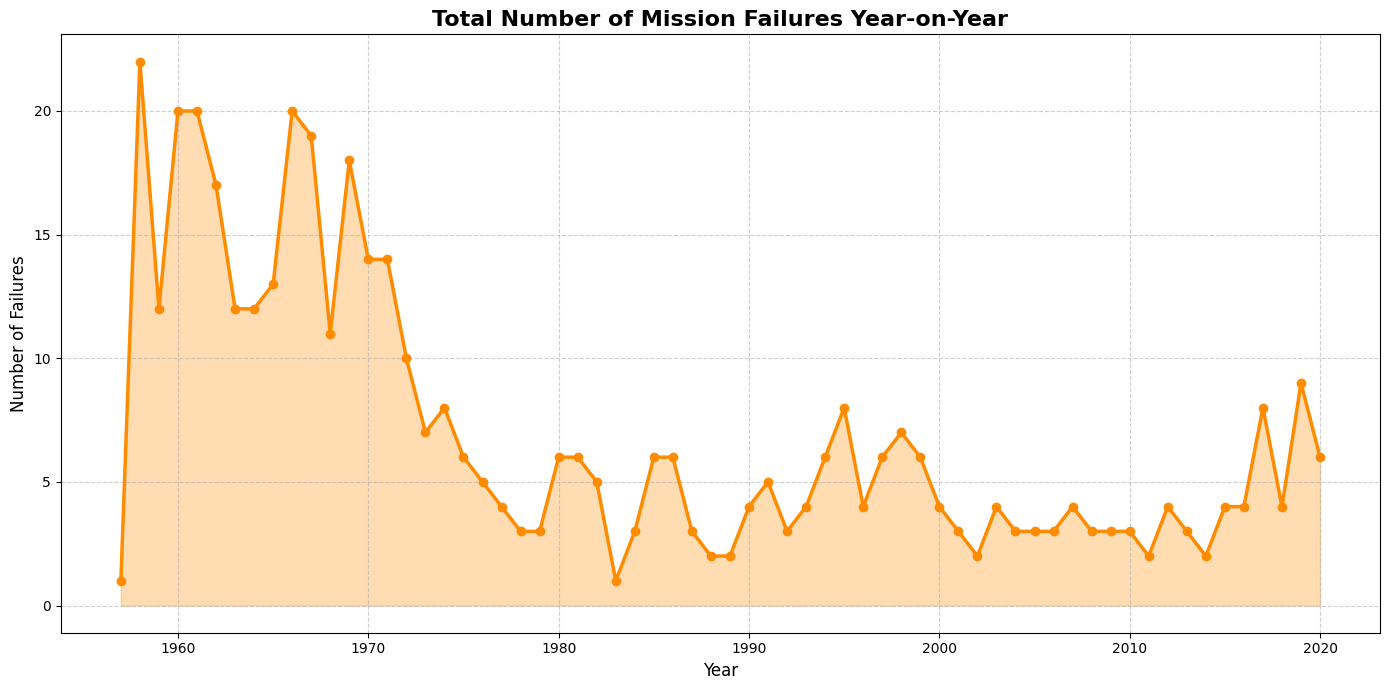

In [41]:
failures_df = df_data.copy()

failures_df['Year'] = failures_df['Date'].str.extract(r'([1-2][0-9]{3})').astype(float)

failures_df = failures_df[failures_df['Mission_Status'].str.contains('Failure', na=False, case=False)]

yearly_failures = failures_df.groupby('Year').size().reset_index(name='Failures')

plt.figure(figsize=(14, 7))
plt.plot(yearly_failures['Year'], yearly_failures['Failures'], marker='o', color='darkorange', linewidth=2.5)
plt.fill_between(yearly_failures['Year'], yearly_failures['Failures'], color='darkorange', alpha=0.3)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Failures', fontsize=12)
plt.title('Total Number of Mission Failures Year-on-Year', fontsize=16, fontweight='bold')
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time?

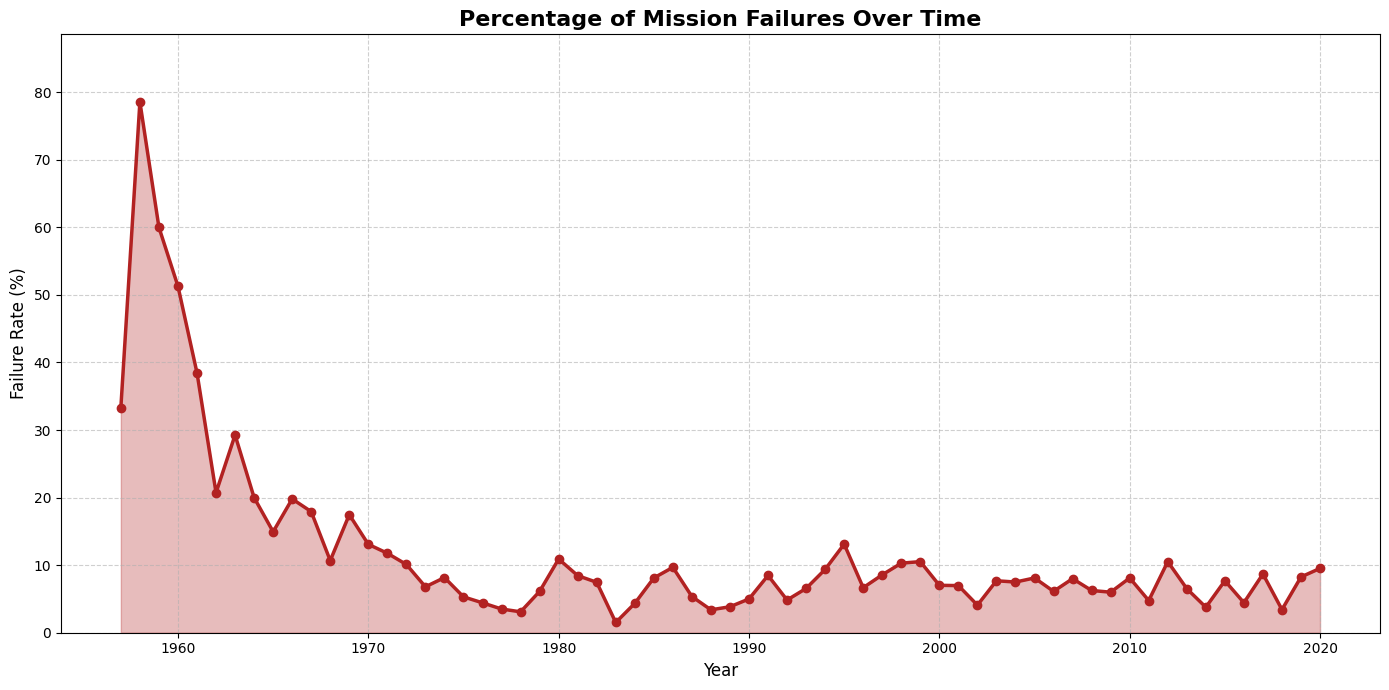

In [44]:
df_clean = df_data.copy()
df_clean['Year'] = df_clean['Date'].str.extract(r'([1-2][0-9]{3})').astype(float)

total_launches = df_clean.groupby('Year').size().reset_index(name='Total_Launches')

failures_df = df_clean[df_clean['Mission_Status'].str.contains('Failure', na=False, case=False)]

yearly_failures = failures_df.groupby('Year').size().reset_index(name='Failures')

failure_stats = pd.merge(total_launches, yearly_failures, on='Year', how='left')
failure_stats['Failures'] = failure_stats['Failures'].fillna(0)
failure_stats['Failure_Percentage'] = (failure_stats['Failures'] / failure_stats['Total_Launches']) * 100

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(failure_stats['Year'], failure_stats['Failure_Percentage'], color='firebrick', marker='o', linewidth=2.5)
plt.fill_between(failure_stats['Year'], failure_stats['Failure_Percentage'], color='firebrick', alpha=0.3)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Failure Rate (%)', fontsize=12)
plt.title('Percentage of Mission Failures Over Time', fontsize=16, fontweight='bold')
plt.grid(axis='both', linestyle='--', alpha=0.6)

max_percent = failure_stats['Failure_Percentage'].max()
plt.ylim(0, max_percent + 10)
plt.tight_layout()

plt.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches?

In [47]:
df_clean = df_data_new.copy()

df_clean['Year'] = df_clean['Date'].str.extract(r'([1-2][0-9]{3})').astype(float)
df_clean = df_clean[df_clean['Year'] <= 2020]

total_launches = df_clean.groupby(['Year', 'Country']).size().reset_index(name='Total_Launches')
idx_total = total_launches.groupby('Year')['Total_Launches'].idxmax()
leader_total = total_launches.loc[idx_total].set_index('Year')

success_df = df_clean[df_clean['Mission_Status'] == 'Success']
success_launches = success_df.groupby(['Year', 'Country']).size().reset_index(name='Successful_Launches')
idx_success = success_launches.groupby('Year')['Successful_Launches'].idxmax()
leader_success = success_launches.loc[idx_success].set_index('Year')

comparison = leader_total[['Country', 'Total_Launches']].join(
    leader_success[['Country', 'Successful_Launches']], rsuffix='_Success'
)
comparison.columns = ['Leader_Total', 'Total_Launches', 'Leader_Success', 'Successful_Launches']

differences = comparison[comparison['Leader_Total'] != comparison['Leader_Success']]

print("Years where the leader changed when ONLY looking at successful launches:")
print(differences)

comparison.to_csv('yearly_leaders_comparison.csv')

Years where the leader changed when ONLY looking at successful launches:
         Leader_Total  Total_Launches      Leader_Success  Successful_Launches
Year                                                                          
1,967.00   Kazakhstan              38  Russian Federation                   33
1,968.00   Kazakhstan              40  Russian Federation                   37
1,993.00          USA              24  Russian Federation                   21
2,020.00        China              22                 USA                   20


# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020?

--- Dominant Organisation(s) in the 1970s and 1980s ---
Organisation
RVSN USSR    20

--- Dominant Organisation in 2018, 2019, and 2020 ---
    Year Organisation  Launches
2,018.00         CASC        37
2,019.00         CASC        27
2,020.00         CASC        19


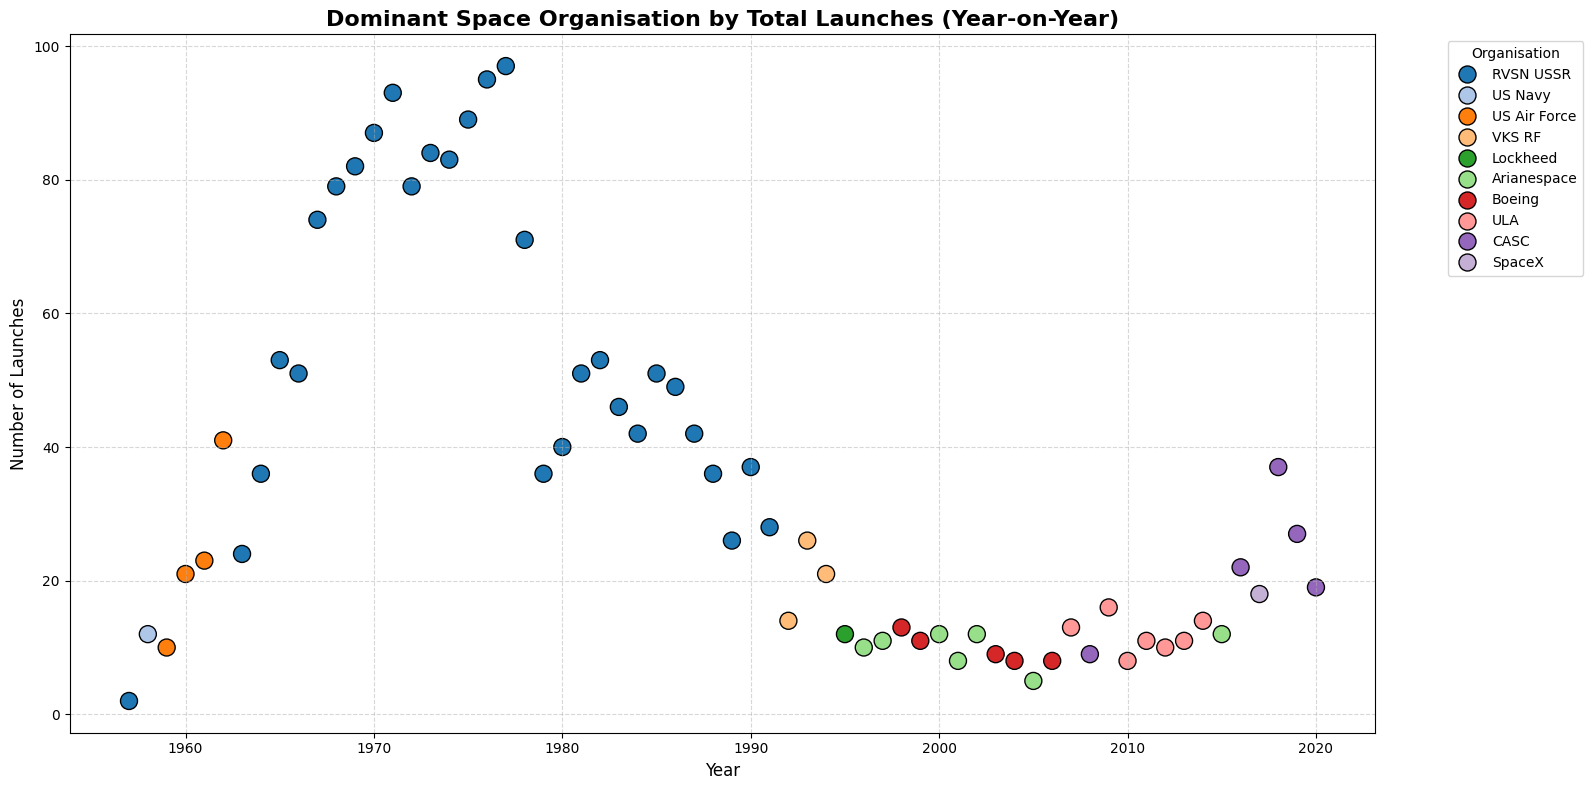

In [48]:
df = df_data.copy()

df['Year'] = df['Date'].str.extract(r'([1-2][0-9]{3})').astype(float)

org_launches = df.groupby(['Year', 'Organisation']).size().reset_index(name='Launches')

idx_max = org_launches.groupby('Year')['Launches'].idxmax()
dominant_orgs = org_launches.loc[idx_max].sort_values('Year').reset_index(drop=True)


print("--- Dominant Organisation(s) in the 1970s and 1980s ---")
seventies_eighties = dominant_orgs[(dominant_orgs['Year'] >= 1970) & (dominant_orgs['Year'] <= 1989)]
print(seventies_eighties['Organisation'].value_counts().to_string())

print("\n--- Dominant Organisation in 2018, 2019, and 2020 ---")
recent_years = dominant_orgs[dominant_orgs['Year'].isin([2018, 2019, 2020])]
print(recent_years[['Year', 'Organisation', 'Launches']].to_string(index=False))


plt.figure(figsize=(16, 8))

sns.scatterplot(
    data=dominant_orgs,
    x='Year',
    y='Launches',
    hue='Organisation',
    s=150,
    palette='tab20',
    edgecolor='black'
)

plt.title('Dominant Space Organisation by Total Launches (Year-on-Year)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Organisation")
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

dominant_orgs.to_csv('dominant_org_per_year.csv', index=False)